In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from ariel_pred.dataset import DataLoaderAndCalibrator
from ariel_pred.preprocessing import SGSmoothing
from ariel_pred.plots import plot_white_curve
from ariel_pred.transit import FunctionFittingBasedPhaseDetector
from ariel_pred.models import TransitMultiplicationFactorFinder, SValuesCNN, SValuesCNNTrainer
from ariel_pred.features import WavelengthsGroupsMultiplierFinder
from ariel_pred.metrics import score, gll
from ariel_pred.sigma import SpectrumVariationScaler
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random
from scipy.optimize import minimize
from tqdm.auto import tqdm
import pandas as pd
import torch
from torch import nn
import scipy

In [3]:
data_loader = DataLoaderAndCalibrator(
    data_path=Path("../data/raw"),
    output_path=Path("../data/calibrated/full"),
    force_recalibration=False,
    cut_airs_channels=True,
    binning=4,
    n_jobs=4
)
train_data, train_labels = data_loader.load_all_train_data()
train_data.shape, train_labels.shape

Loading calibrated train data...


((1100, 1406, 283), (1100, 283))

In [4]:
features_extractor = WavelengthsGroupsMultiplierFinder()

features = features_extractor.extract_features(
    train_data,
)

features.shape

100%|██████████| 1100/1100 [03:24<00:00,  5.37it/s]


(1100, 283)

In [6]:
rmse = np.sqrt(np.mean((features - train_labels) ** 2, axis=1))
rmse.shape

(1100,)

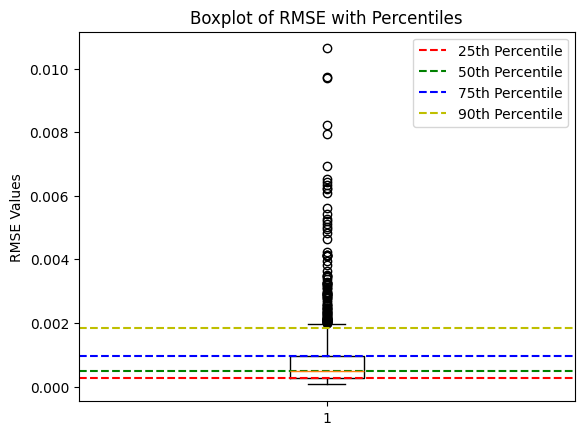

In [9]:
plt.boxplot(rmse)
plt.axhline(np.percentile(rmse, 25), color='r', linestyle='--', label='25th Percentile')
plt.axhline(np.percentile(rmse, 50), color='g', linestyle='--', label='50th Percentile')
plt.axhline(np.percentile(rmse, 75), color='b', linestyle='--', label='75th Percentile')
plt.axhline(np.percentile(rmse, 90), color='y', linestyle='--', label='90th Percentile')
plt.legend()
plt.title('Boxplot of RMSE with Percentiles')
plt.ylabel('RMSE Values')
plt.show()